# Simulação de Dinâmica de Voo - Aeronave Vesper (CB-07)

## 1. Configuração do Ambiente e Modelo Físico
Nesta seção, importamos as bibliotecas necessárias e definimos as funções governantes da simulação:
1.  **Entradas de Controle:** Funções para gerar sinais de *Doublet* e *Pulse*.
2.  **Equações de Movimento:** Implementação das equações de Euler-Newton para um corpo rígido com 6 graus de liberdade (6-DOF), utilizando expansão de Taylor para os coeficientes aerodinâmicos.

In [48]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from math import sin, cos, tan, asin, atan, sqrt, pi, degrees, radians

# =============================================================================
# FUNÇÃO DE INPUT DO PILOTO (GERADOR DE SINAL)
# =============================================================================
def get_control_input(t, input_type, surface, amplitude_deg):
    """
    Gera o sinal de perturbação (delta) a ser somado ao trim.
    """
    amp = radians(amplitude_deg)
    pert = 0.0
    
    # Configuração temporal da manobra
    t_start = 10.0      # Início da perturbação
    duration = 1.0     # Duração de cada pulso
    
    if input_type == 'pulse':
        if t_start <= t < (t_start + duration):
            pert = amp
            
    elif input_type == 'doublet':
        if t_start <= t < (t_start + duration):
            pert = amp        # Parte positiva
        elif (t_start + duration) <= t < (t_start + 2*duration):
            pert = -amp       # Parte negativa (invertida)
            
    # Retorna tupla (delta_aileron, delta_elevator, delta_rudder)
    da, de, dr = 0, 0, 0
    if surface == 'aileron': da = pert
    elif surface == 'elevator': de = pert
    elif surface == 'rudder': dr = pert
    
    return da, de, dr

# =============================================================================
# EQUAÇÕES DE MOVIMENTO (6-DOF)
# =============================================================================
def equations_of_motion(t, state, config, sim_type):
    """
    Calcula as derivadas de estado (acelerações/velocidades) para o integrador.
    Args:
        state: Vetor de 12 variáveis [u,v,w, p,q,r, phi,theta,psi, x,y,h]
        config: Dicionário contendo TODOS os dados da aeronave (Massa, Inércia, Derivadas)
        sim_type: Dicionário com o tipo de simulação (ex: {'type': 'doublet', 'surf': 'elevator'})
    """
    # 1. Desempacotar Estado
    u, v, w, p, q, r, phi, theta, psi, x, y, h = state
    
    # 2. Extrair Parâmetros da Configuração Atual
    params = config['params']       # Massa, geometria, inércia
    derivs = config['derivatives']  # Derivadas aerodinâmicas
    trim   = config['trim']         # Condições de trimagem (alpha0, de0)
    
    # 3. Variáveis Auxiliares
    V_tot = sqrt(u**2 + v**2 + w**2)
    if V_tot < 0.1: V_tot = 0.1 # Evitar div/0
    
    alpha = atan(w/u)
    beta = asin(v/V_tot)
    q_bar = 0.5 * params['rho'] * V_tot**2 
    
    # Taxas normalizadas
    p_hat = p * params['b'] / (2 * V_tot)
    q_hat = q * params['c'] / (2 * V_tot)
    r_hat = r * params['b'] / (2 * V_tot)
    
    # 4. Comandos Totais (Trim + Perturbação)
    # Pega a perturbação do piloto
    pert_a, pert_e, pert_r = get_control_input(t, sim_type['type'], sim_type['surface'], sim_type['amp'])
    
    # Soma ao estado de equilíbrio (Trim)
    da = pert_a # Aileron trim é 0
    de = trim['delta_e_rad'] + pert_e
    dr = pert_r # Leme trim é 0
    
    # Deltas para cálculo (diferença do equilíbrio)
    d_alpha = alpha - trim['alpha_rad']
    d_de    = de - trim['delta_e_rad']
    
    # 5. Coeficientes Aerodinâmicos (Série de Taylor)
    # Sustentação (L)
    CL = (derivs['CL_ref'] + derivs['CL_a']*d_alpha + 
          derivs['CL_de']*d_de + derivs['CL_q']*q_hat)
    
    # Arrasto (D) - Modelo polar simples
    CD = derivs['CD_ref'] # Pode-se adicionar termo induzido aqui se desejar sofisticação
    
    # Momento de Arfagem (m)
    Cm = (derivs['Cm_ref'] + derivs['Cm_a']*d_alpha + 
          derivs['Cm_de']*d_de + derivs['Cm_q']*q_hat)
          
    # Laterais (Y, l, n)
    CY = (derivs['CY_b']*beta + derivs['CY_p']*p_hat + derivs['CY_r']*r_hat + 
          derivs['CY_dr']*dr + derivs['CY_da']*da)
          
    Cl = (derivs['Cl_b']*beta + derivs['Cl_p']*p_hat + derivs['Cl_r']*r_hat + 
          derivs['Cl_dr']*dr + derivs['Cl_da']*da)
          
    Cn = (derivs['Cn_b']*beta + derivs['Cn_p']*p_hat + derivs['Cn_r']*r_hat + 
          derivs['Cn_dr']*dr + derivs['Cn_da']*da)
    
    # 6. Forças Dimensionais (Eixo do Corpo)
    # Conversão Estabilidade -> Corpo
    CX = -CD * cos(alpha) + CL * sin(alpha)
    CZ = -CD * sin(alpha) - CL * cos(alpha)
    
    # Tração (Fixa no valor de trimagem para manter velocidade inicial)
    # T = Drag_trim
    Drag_trim = derivs['CD_ref'] * (0.5 * params['rho'] * trim['V']**2) * params['S']
    Thrust = Drag_trim 
    
    Fx = CX * q_bar * params['S'] + Thrust
    Fy = CY * q_bar * params['S']
    Fz = CZ * q_bar * params['S']
    
    L_mom = Cl * q_bar * params['S'] * params['b']
    M_mom = Cm * q_bar * params['S'] * params['c']
    N_mom = Cn * q_bar * params['S'] * params['b']
    
    # 7. Newton-Euler (Acelerações)
    Ix, Iy, Iz = params['Ixx'], params['Iyy'], params['Izz']
    
    u_dot = (Fx/params['m']) - params['g']*sin(theta) + r*v - q*w
    v_dot = (Fy/params['m']) + params['g']*sin(phi)*cos(theta) - r*u + p*w
    w_dot = (Fz/params['m']) + params['g']*cos(phi)*cos(theta) + q*u - p*v
    
    p_dot = (L_mom - (Iz - Iy)*q*r) / Ix
    q_dot = (M_mom - (Ix - Iz)*p*r) / Iy
    r_dot = (N_mom - (Iy - Ix)*p*q) / Iz
    
    # 8. Cinemática
    phi_dot   = p + (q*sin(phi) + r*cos(phi)) * tan(theta)
    theta_dot = q*cos(phi) - r*sin(phi)
    psi_dot   = (q*sin(phi) + r*cos(phi)) / cos(theta)
    
    # 9. Navegação
    c_th, s_th = cos(theta), sin(theta)
    c_ph, s_ph = cos(phi), sin(phi)
    c_ps, s_ps = cos(psi), sin(psi)
    
    x_dot = u*c_th*c_ps + v*(s_ph*s_th*c_ps - c_ph*s_ps) + w*(c_ph*s_th*c_ps + s_ph*s_ps)
    y_dot = u*c_th*s_ps + v*(s_ph*s_th*s_ps + c_ph*c_ps) + w*(c_ph*s_th*s_ps - s_ph*c_ps)
    h_dot = u*s_th      - v*s_ph*c_th                    - w*c_ph*c_th
    
    return [u_dot, v_dot, w_dot, p_dot, q_dot, r_dot, phi_dot, theta_dot, psi_dot, x_dot, y_dot, h_dot]

---
# 2. Análise do Caso Base (Baseline)
**Configuração:** Massa 740kg | CG 31.8% (0.34m) | Altitude 2700m

Nesta seção, executamos a bateria completa de testes para a configuração padrão da aeronave. O objetivo é caracterizar a estabilidade dinâmica longitudinal (Fugoide e Curto Período) e látero-direcional (Dutch Roll, Espiral e Rolamento) antes de aplicar as variações de sensibilidade.

**Cenários Simulados:**
1.  **Profundor (Longitudinal):** Doublet e Pulso.
2.  **Aileron (Lateral):** Doublet e Pulso.
3.  **Leme (Direcional):** Doublet e Pulso.

In [49]:
# =============================================================================
# CONFIGURAÇÃO BASE (740kg, CG 31.8%)
# =============================================================================

# Dicionário contendo todos os parâmetros da aeronave para esta configuração
CONFIG_BASE = {
    'name': 'Base (740kg, CG 34cm)',
    
    # Parâmetros Físicos e Geométricos
    'params': {
        'm': 740.0,       # Massa (kg)
        'S': 17.87,       # Área alar (m2)
        'b': 17.5,        # Envergadura (m)
        'c': 1.07,        # Corda Média (m)
        'g': 9.798,       # Gravidade local
        'rho': 0.871,     # Densidade do ar (2700m)
        
        # Momentos de Inércia (Do seu arquivo .mass)
        'Ixx': 3541.0,
        'Iyy': 1697.0,
        'Izz': 4564.0,
        'Ixz': 0.0,
    },
    
    # Condições de Trimagem (Do output 'X' do AVL)
    'trim': {
        'V': 62.22,
        'alpha_rad': radians(-4.42730),
        'delta_e_rad': radians(7.72590),
    },
    
    # Derivadas de Estabilidade (Do output 'ST' do AVL)
    # IMPORTANTE: Multiplicamos por (180/pi) se o valor for "por grau"
    'derivatives': {
        # --- Longitudinais ---
        'CL_ref': 0.24066,         # CLtot
        'CD_ref': 0.00125 * 10,     # CDtot * 10 (Correção viscosa)
        
        'CL_a': 5.914984,          # CLa (rad)
        'CL_q': 9.820488,          # CLq (rad)
        'CL_de': 0.005135 * (180/pi), # CLd2 (Elevator)
        
        'Cm_ref': 0.0,             # Trimado
        'Cm_a': -1.621203,         # Cma (Estabilidade Estática)
        'Cm_q': -21.469688,        # Cmq (Amortecimento de Pitch)
        'Cm_de': -0.024407 * (180/pi), # Cmd2 (Potência do profundor)
        
        # --- Látero-Direcionais ---
        'CY_b': -0.178871,         # CYb
        'CY_p': -0.071845,
        'CY_r': 0.118310,
        'CY_da': -0.000460 * (180/pi), # Aileron (d1)
        'CY_dr': 0.002201 * (180/pi),  # Rudder (d3)
        
        'Cl_b': -0.059694,         # Clb (Diedro)
        'Cl_p': -0.644561,         # Clp (Roll Damping)
        'Cl_r': 0.079212,
        'Cl_da': -0.005787 * (180/pi), # Cld1 (Aileron Power)
        'Cl_dr': 0.000148 * (180/pi),  # Cld3
        
        'Cn_b': 0.045132,          # Cnb (Estabilidade Direcional)
        'Cn_p': -0.022013,
        'Cn_r': -0.030761,         # Cnr (Yaw Damping)
        'Cn_da': 0.000528 * (180/pi),  # Cnd1 (Adverse Yaw)
        'Cn_dr': -0.000667 * (180/pi), # Cnd3 (Rudder Power)
    }
}

print("Configuração BASE carregada com sucesso.")

Configuração BASE carregada com sucesso.


--- Iniciando Análise: Base (740kg, CG 34cm) ---


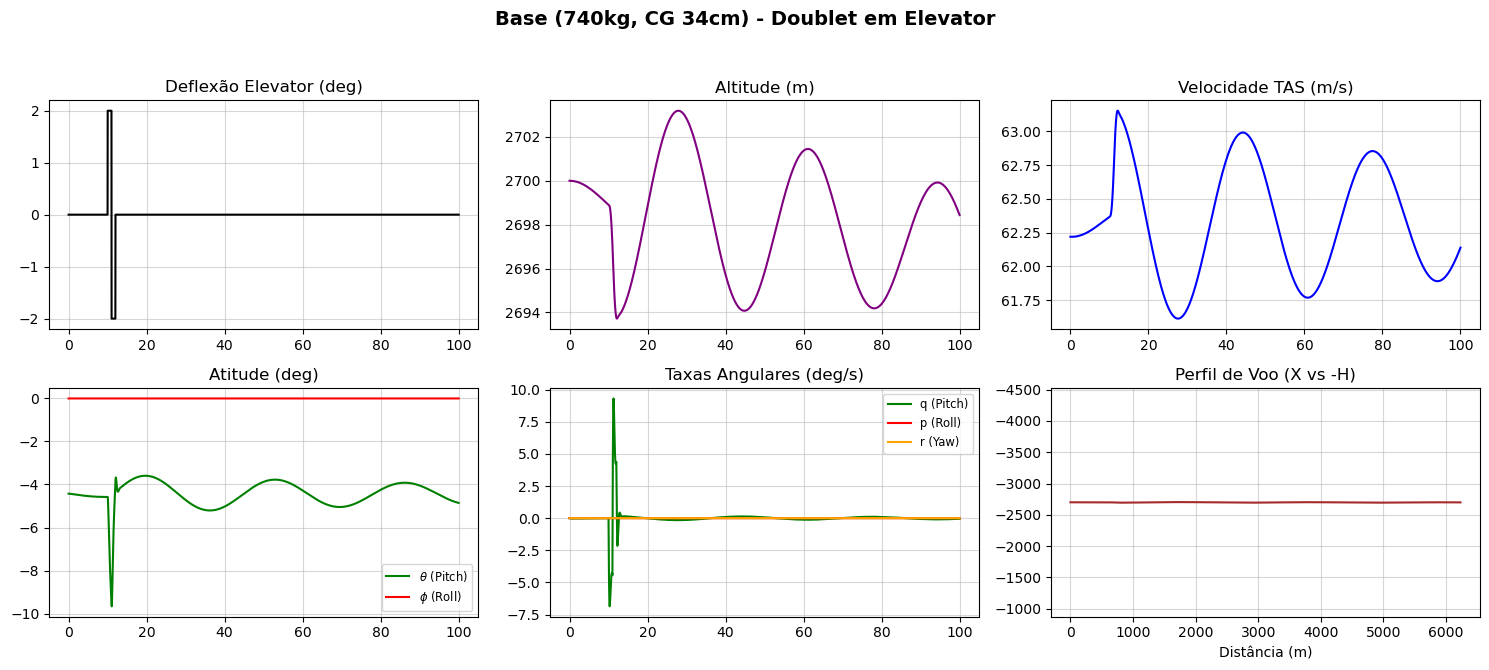

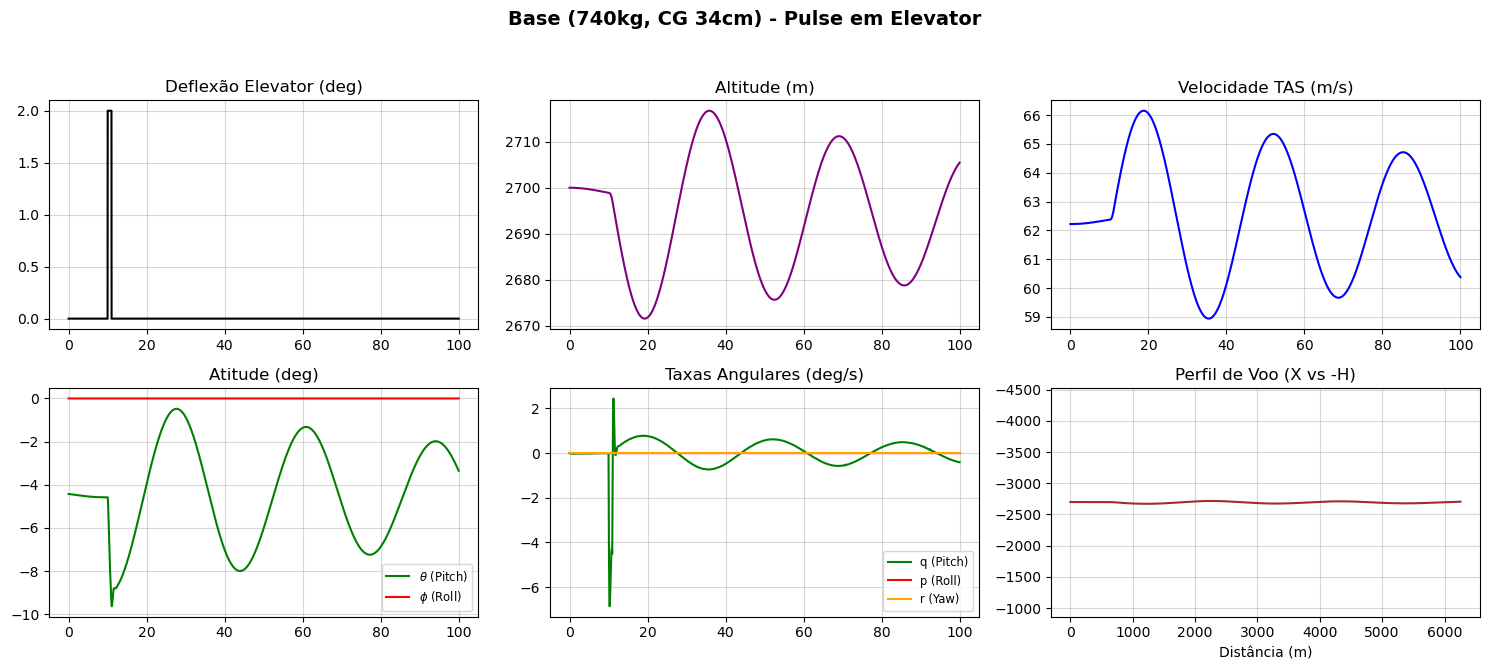

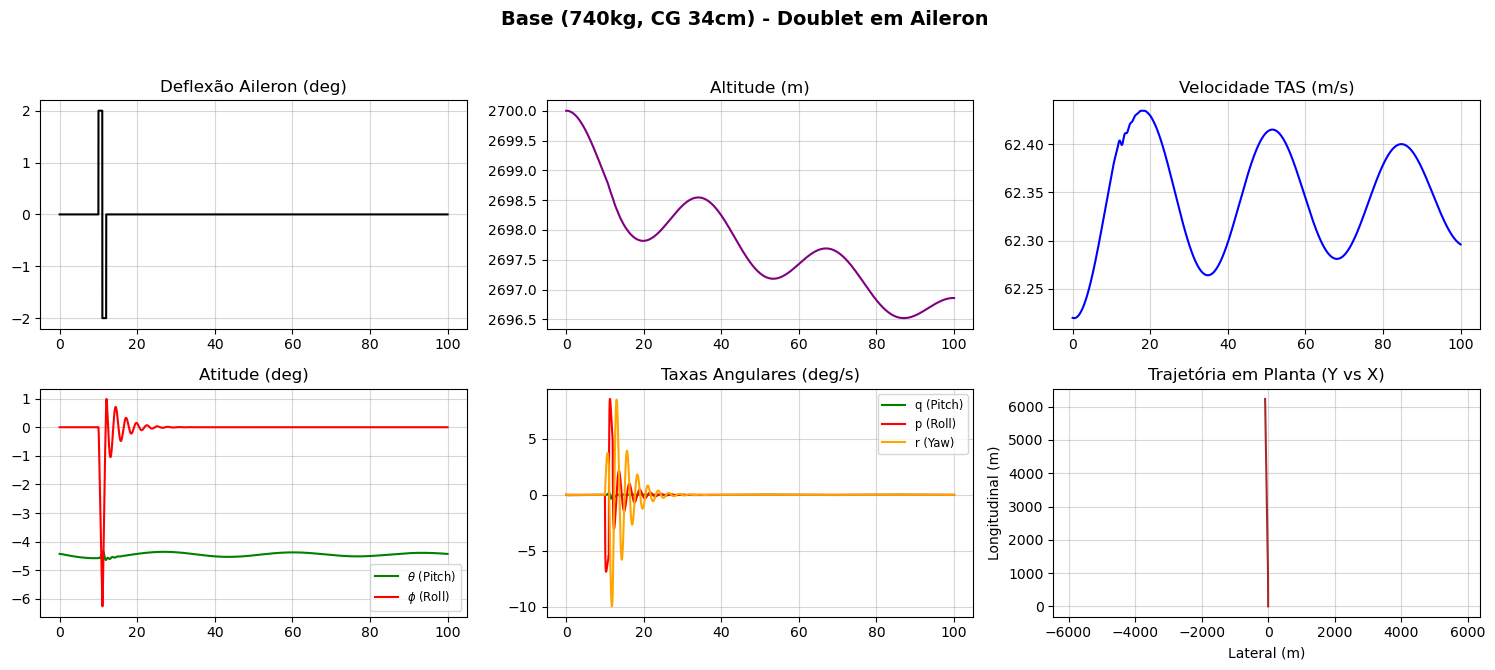

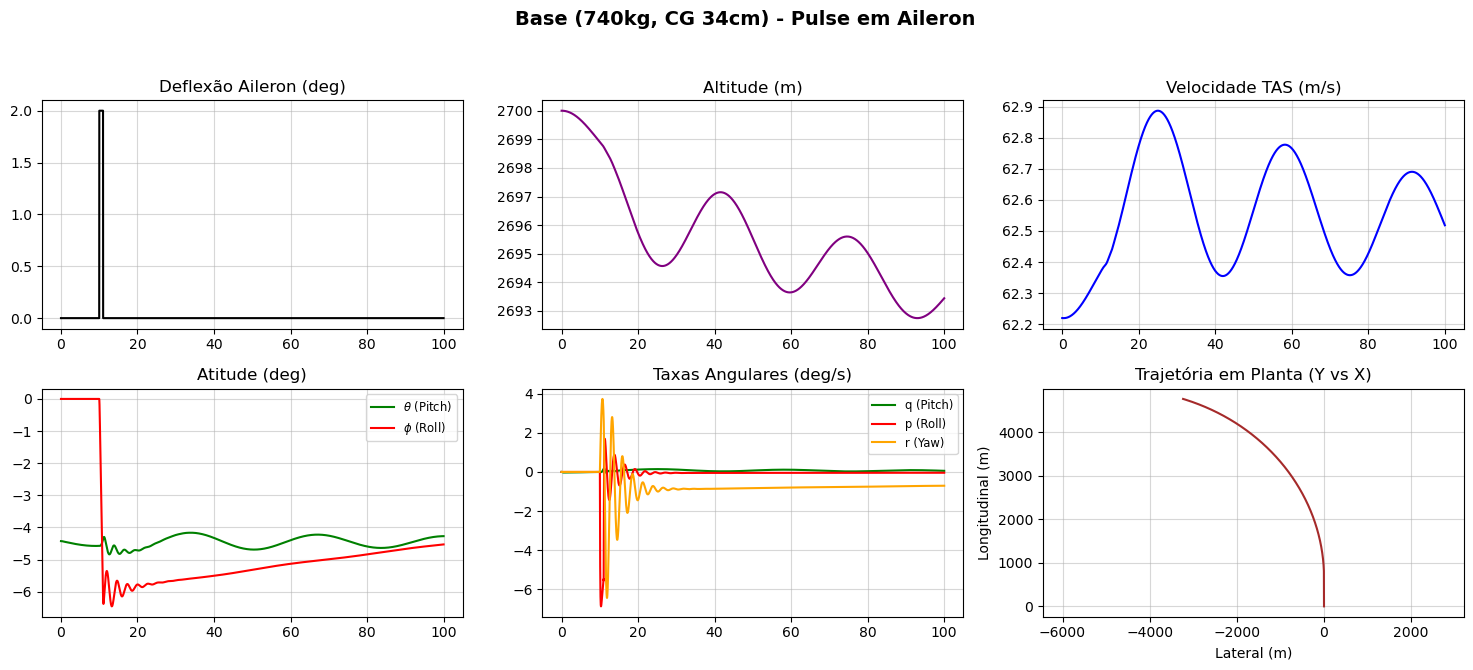

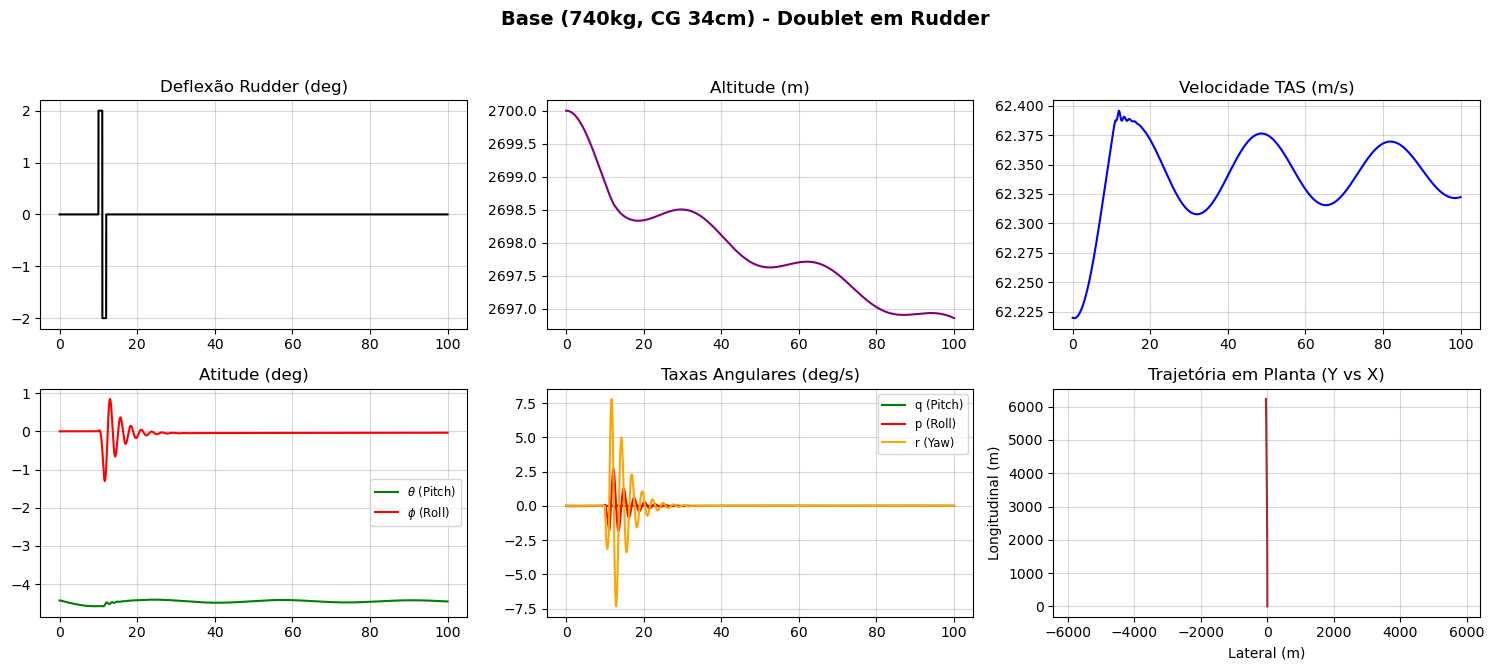

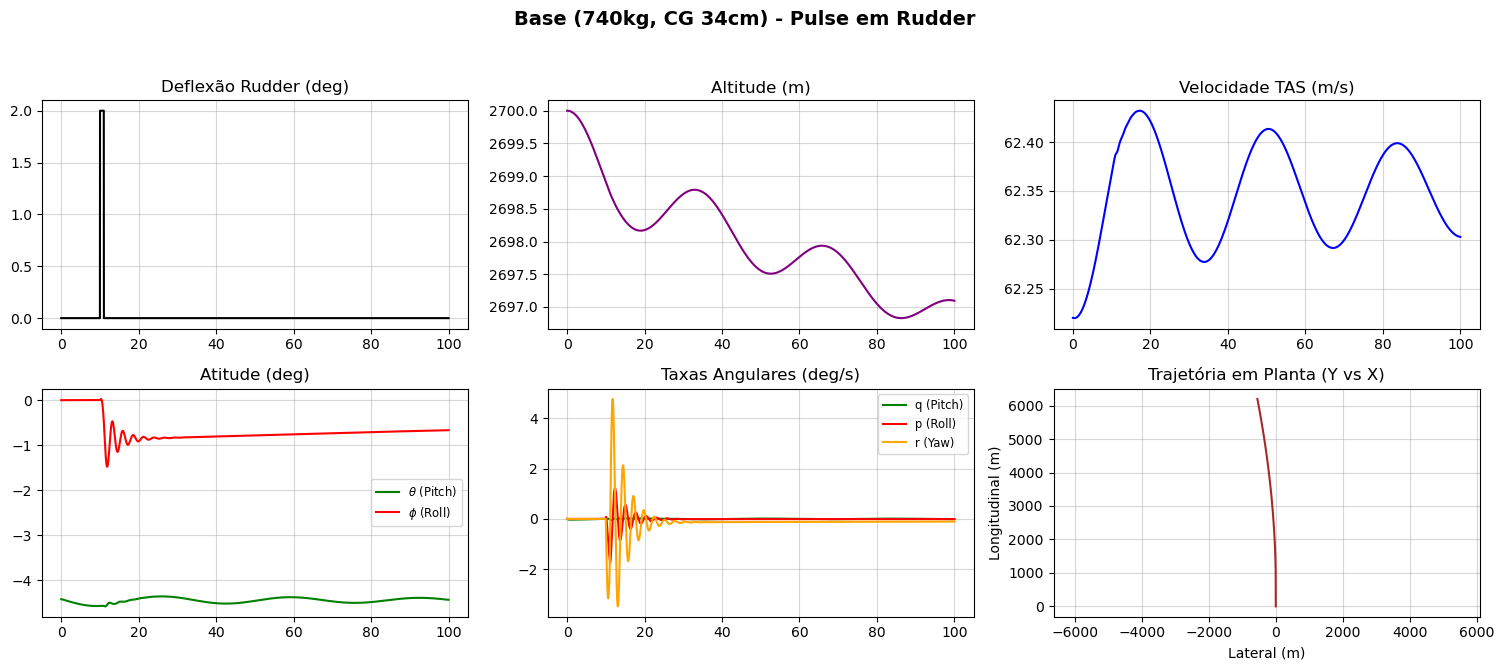

In [50]:
# =============================================================================
# 3. ROTINA DE EXECUÇÃO E PLOTAGEM (BATCH)
# =============================================================================

def plot_results(sol, sim_setup, config_name):
    """Gera um grid 2x3 compacto com os principais estados da simulação."""
    t = sol.t
    # Conversão de radianos para graus para plotagem
    u, v, w = sol.y[0], sol.y[1], sol.y[2]
    p, q, r = np.degrees(sol.y[3]), np.degrees(sol.y[4]), np.degrees(sol.y[5])
    phi, theta, psi = np.degrees(sol.y[6]), np.degrees(sol.y[7]), np.degrees(sol.y[8])
    h = sol.y[11]
    V_tas = np.sqrt(u**2 + v**2 + w**2)
    alpha = np.degrees(np.arctan2(w, u))
    
    # Layout compacto
    fig, axs = plt.subplots(2, 3, figsize=(15, 7))
    title_str = f"{config_name} - {sim_setup['type'].title()} em {sim_setup['surface'].title()}"
    fig.suptitle(title_str, fontsize=14, weight='bold')
    
    # 1. Comandos (Reconstrução visual)
    ctrl_sigs = [get_control_input(ti, sim_setup['type'], sim_setup['surface'], sim_setup['amp']) for ti in t]
    # Extrai apenas o canal ativo para plotar
    idx_map = {'aileron': 0, 'elevator': 1, 'rudder': 2}
    active_ctrl = [c[idx_map[sim_setup['surface']]] for c in ctrl_sigs]
    axs[0, 0].plot(t, np.degrees(active_ctrl), color='black')
    axs[0, 0].set_title(f'Deflexão {sim_setup["surface"].title()} (deg)')
    axs[0, 0].grid(True, alpha=0.5)

    # 2. Altitude (h)
    axs[0, 1].plot(t, h, color='purple')
    axs[0, 1].set_title('Altitude (m)')
    axs[0, 1].grid(True, alpha=0.5)
    
    # 3. Velocidade (TAS)
    axs[0, 2].plot(t, V_tas, color='blue')
    axs[0, 2].set_title('Velocidade TAS (m/s)')
    axs[0, 2].grid(True, alpha=0.5)

    # 4. Ângulos de Atitude (Euler)
    axs[1, 0].plot(t, theta, label=r'$\theta$ (Pitch)', color='green')
    axs[1, 0].plot(t, phi, label=r'$\phi$ (Roll)', color='red')
    axs[1, 0].legend(loc='best', fontsize='small')
    axs[1, 0].set_title('Atitude (deg)')
    axs[1, 0].grid(True, alpha=0.5)

    # 5. Taxas Angulares (p, q, r)
    axs[1, 1].plot(t, q, label='q (Pitch)', color='green')
    axs[1, 1].plot(t, p, label='p (Roll)', color='red')
    axs[1, 1].plot(t, r, label='r (Yaw)', color='orange')
    axs[1, 1].legend(loc='best', fontsize='small')
    axs[1, 1].set_title('Taxas Angulares (deg/s)')
    axs[1, 1].grid(True, alpha=0.5)

    # 6. Trajetória 2D (Perfil ou Planta dependendo da manobra)
    if sim_setup['surface'] == 'elevator':
        axs[1, 2].plot(sol.y[9], -sol.y[11], color='brown') # X vs -H (Perfil)
        axs[1, 2].set_title('Perfil de Voo (X vs -H)')
        axs[1, 2].set_xlabel('Distância (m)')
        axs[1, 2].invert_yaxis() # Para mostrar altitude intuitivamente
    else:
        axs[1, 2].plot(sol.y[10], sol.y[9], color='brown') # Y vs X (Planta)
        axs[1, 2].set_title('Trajetória em Planta (Y vs X)')
        axs[1, 2].set_xlabel('Lateral (m)')
        axs[1, 2].set_ylabel('Longitudinal (m)')
    axs[1, 2].grid(True, alpha=0.5)
    axs[1, 2].axis('equal')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para o título geral
    plt.show()

def run_analysis_batch(config):
    """
    Roda a bateria completa de 6 simulações para uma dada configuração.
    """
    print(f"--- Iniciando Análise: {config['name']} ---")
    
    # Condições Iniciais de Trimagem
    trim = config['trim']
    # Estado: [u, v, w, p, q, r, phi, theta, psi, x, y, h]
    # u0 = V*cos(alpha), w0 = V*sin(alpha)
    y0 = [
        trim['V'] * cos(trim['alpha_rad']), # u
        0.0,                                # v
        trim['V'] * sin(trim['alpha_rad']), # w
        0, 0, 0,                            # p, q, r
        0, trim['alpha_rad'], 0,            # phi, theta, psi (Theta=Alpha no trim)
        0, 0, 2700.0                        # x, y, h
    ]
    
    # Lista de Cenários
    scenarios = [
        {'surface': 'elevator', 'type': 'doublet', 'amp': 2.0, 't_end': 100},
        {'surface': 'elevator', 'type': 'pulse',   'amp': 2.0, 't_end': 100},
        {'surface': 'aileron',  'type': 'doublet', 'amp': 2.0, 't_end': 100},
        {'surface': 'aileron',  'type': 'pulse',   'amp': 2.0, 't_end': 100},
        {'surface': 'rudder',   'type': 'doublet', 'amp': 2.0, 't_end': 100},
        {'surface': 'rudder',   'type': 'pulse',   'amp': 2.0, 't_end': 100},
    ]
    
    for sim in scenarios:
        # Configuração temporal
        t_span = (0, sim['t_end'])
        t_eval = np.linspace(0, sim['t_end'], int(sim['t_end']*100))
        
        # Solver
        sol = solve_ivp(
            lambda t, y: equations_of_motion(t, y, config, sim),
            t_span, y0, t_eval=t_eval, method='RK45'
        )
        
        # Plotar
        plot_results(sol, sim, config['name'])

# =============================================================================
# EXECUTAR CASO BASE
# =============================================================================
# Roda todas as simulações para a configuração definida no Bloco 2
run_analysis_batch(CONFIG_BASE)

In [51]:
def run_comparative_batch(configs_list, zoom=False, title_prefix="Sensibilidade"):
    """
    Roda a bateria comparativa.
    Se zoom=True, foca nos primeiros 20s para análise de Curto Período e Dutch Roll.
    Se zoom=False, mostra 600s para Fugóide e Espiral.
    """
    colors = ['blue', 'orange', 'red']
    linestyles = ['-', '--', '-.']
    
    # Define o tempo final com base no zoom
    t_final = 100 if zoom else 600
    
    scenarios = [
        {'surface': 'elevator', 'type': 'doublet', 'amp': 2.0, 't_end': t_final},
        {'surface': 'elevator', 'type': 'pulse',   'amp': 2.0, 't_end': t_final},
        {'surface': 'aileron',  'type': 'doublet', 'amp': 2.0, 't_end': t_final},
        {'surface': 'aileron',  'type': 'pulse',   'amp': 2.0, 't_end': t_final},
        {'surface': 'rudder',   'type': 'doublet', 'amp': 2.0, 't_end': t_final},
        {'surface': 'rudder',   'type': 'pulse',   'amp': 2.0, 't_end': t_final},
    ]
    
    print(f"--- GERANDO GRÁFICOS COMPARATIVOS (ZOOM={'LIGADO' if zoom else 'DESLIGADO'}) ---")

    for sim in scenarios:
        fig, axs = plt.subplots(2, 3, figsize=(16, 8))
        suffix = "" if zoom else " (600s)"
        fig_title = f"{title_prefix} - {sim['type'].title()} em {sim['surface'].title()}{suffix}"
        fig.suptitle(fig_title, fontsize=16, weight='bold')
        
        for i, conf in enumerate(configs_list):
            # Setup e Solver (Idêntico ao seu)
            trim = conf['trim']
            y0 = [
                trim['V'] * cos(trim['alpha_rad']), 0.0, trim['V'] * sin(trim['alpha_rad']), 
                0, 0, 0, 
                0, trim['alpha_rad'], 0, 
                0, 0, 2700.0
            ]
            
            t_span = (0, sim['t_end'])
            t_eval = np.linspace(0, sim['t_end'], int(sim['t_end']*100))
            
            sol = solve_ivp(
                lambda t, y: equations_of_motion(t, y, conf, sim),
                t_span, y0, t_eval=t_eval, method='RK45'
            )
            
            # Extração de dados
            t = sol.t
            u, v, w = sol.y[0], sol.y[1], sol.y[2]
            p, q, r = np.degrees(sol.y[3]), np.degrees(sol.y[4]), np.degrees(sol.y[5])
            phi, theta, psi = np.degrees(sol.y[6]), np.degrees(sol.y[7]), np.degrees(sol.y[8])
            h = sol.y[11]
            V_tas = np.sqrt(u**2 + v**2 + w**2)
            
            lbl = conf['name']
            c = colors[i]
            ls = linestyles[0]
            
            # --- PLOTAGEM ---
            
            # 1. Comando
            if i == 0:
                idx_map = {'aileron': 0, 'elevator': 1, 'rudder': 2}
                ctrl = [np.degrees(get_control_input(ti, sim['type'], sim['surface'], sim['amp'])[idx_map[sim['surface']]]) for ti in t]
                axs[0, 0].plot(t, ctrl, color='black')
                axs[0, 0].set_title(f'Input {sim["surface"].title()}')

            # 2. Altitude
            axs[0, 1].plot(t, h, label=lbl, color=c, linestyle=ls)
            axs[0, 1].set_title('Altitude (m)')
            
            # 3. Velocidade
            axs[0, 2].plot(t, V_tas, label=lbl, color=c, linestyle=ls)
            axs[0, 2].set_title('Velocidade TAS (m/s)')
            
            # 4. Atitude (Inteligente)
            if sim['surface'] == 'elevator':
                axs[1, 0].plot(t, theta, label=lbl, color=c, linestyle=ls)
                axs[1, 0].set_title('Atitude Theta (Pitch)')
            else:
                axs[1, 0].plot(t, phi, label=lbl, color=c, linestyle=ls)
                axs[1, 0].set_title('Atitude Phi (Roll)')
                
            # 5. Taxas (MELHORADO)
            if sim['surface'] == 'elevator':
                axs[1, 1].plot(t, q, label=lbl, color=c, linestyle=ls)
                axs[1, 1].set_title('Pitch Rate q (deg/s)') # Crucial para Curto Período
            elif sim['surface'] == 'aileron':
                axs[1, 1].plot(t, p, label=lbl, color=c, linestyle=ls)
                axs[1, 1].set_title('Roll Rate p (deg/s)') # Crucial para Aileron
            else: # Rudder
                axs[1, 1].plot(t, r, label=lbl, color=c, linestyle=ls)
                axs[1, 1].set_title('Yaw Rate r (deg/s)') # Crucial para Dutch Roll

            # 6. Trajetória
            if sim['surface'] == 'elevator':
                axs[1, 2].plot(sol.y[9], -h, color=c, linestyle=ls)
                axs[1, 2].set_title('Perfil (X vs -H)')
                if i == 2: axs[1, 2].invert_yaxis()
            else:
                axs[1, 2].plot(sol.y[10], sol.y[9], color=c, linestyle=ls)
                axs[1, 2].set_title('Planta (Y vs X)')

        for ax in axs.flat:
            ax.grid(True, alpha=0.3)
            if ax != axs[0,0]: ax.legend(fontsize='x-small')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

---
# 3. Análise de Sensibilidade: Posição do Centro de Gravidade (CG)
**Objetivo:** Avaliar a degradação da estabilidade estática e dinâmica longitudinal conforme o Centro de Gravidade é deslocado para trás.

Mantendo a massa constante em **740 kg** (Configuração Pesada), foram analisadas três posições de CG, cobrindo o envelope operacional típico da aeronave (30% a 37% da CMA):

| Configuração | Posição do CG (% CMA) | Posição X (m) | Descrição |
| :--- | :---: | :---: | :--- |
|🔵 **Caso Base** | **31.8%** | **0.34 m** | Configuração nominal de estabilidade (Já analisada). |
| 🟠**Variação 1** | **34.6%** | **0.37 m** | Posição intermediária. |
| 🔴**Variação 2** | **37.4%** | **0.40 m** | Configuração recuada do CG. |

Abaixo, definimos as novas configurações aerodinâmicas obtidas via AVL para as variações 1 e 2.

In [52]:
# =============================================================================
# VARIAÇÃO 1: CG INTERMEDIÁRIO (X_cg = 0.37m)
# =============================================================================
CONFIG_VAR1 = {
    'name': 'Variação 1 (CG 0.37m)',
    
    'params': {
        'm': 740.0,       
        'S': 17.87, 'b': 17.5, 'c': 1.07,
        'g': 9.798, 'rho': 0.871,
        'Ixx': 3541.0, 'Iyy': 1697.0, 'Izz': 4564.0, 'Ixz': 0.0,
    },
    
    'trim': {
        'V': 62.22,
        'alpha_rad': radians(-4.44206), # Do log X (0.37)
        'delta_e_rad': radians(8.02216),# Do log X (0.37)
    },
    
    'derivatives': {
        # --- Longitudinais ---
        'CL_ref': 0.24066,
        'CD_ref': 0.00124 * 10, # Correção viscosa
        
        'CL_a': 5.915169, 
        'CL_q': 9.481948, 
        'CL_de': 0.005135 * (180/pi),
        
        'Cm_ref': 0.0,
        'Cm_a': -1.456983,          # Note a redução da estabilidade (era -1.62)
        'Cm_q': -21.075382,
        'Cm_de': -0.024254 * (180/pi),
        
        # --- Látero-Direcionais ---
        'CY_b': -0.178751,
        'CY_p': -0.071827,
        'CY_r': 0.117581,
        'CY_da': -0.000460 * (180/pi),
        'CY_dr': 0.002199 * (180/pi),
        
        'Cl_b': -0.059649,
        'Cl_p': -0.644542,
        'Cl_r': 0.078669,
        'Cl_da': -0.005787 * (180/pi),
        'Cl_dr': 0.000148 * (180/pi),
        
        'Cn_b': 0.044797,
        'Cn_p': -0.022039,
        'Cn_r': -0.030376,
        'Cn_da': 0.000528 * (180/pi),
        'Cn_dr': -0.000662 * (180/pi),
    }
}

# =============================================================================
# VARIAÇÃO 2: CG TRASEIRO (X_cg = 0.40m)
# =============================================================================
CONFIG_VAR2 = {
    'name': 'Variação 2 (CG 0.40m)',
    
    'params': {
        'm': 740.0,       
        'S': 17.87, 'b': 17.5, 'c': 1.07,
        'g': 9.798, 'rho': 0.871,
        'Ixx': 3541.0, 'Iyy': 1697.0, 'Izz': 4564.0, 'Ixz': 0.0,
    },
    
    'trim': {
        'V': 62.22,
        'alpha_rad': radians(-4.45684), # Do log X (0.40)
        'delta_e_rad': radians(8.31863),# Do log X (0.40)
    },
    
    'derivatives': {
        # --- Longitudinais ---
        'CL_ref': 0.24066,
        'CD_ref': 0.00124 * 10, 
        
        'CL_a': 5.915355, 
        'CL_q': 9.143402, 
        'CL_de': 0.005135 * (180/pi),
        
        'Cm_ref': 0.0,
        'Cm_a': -1.292767,          # Redução drástica (-1.62 -> -1.29)
        'Cm_q': -20.699976,
        'Cm_de': -0.024102 * (180/pi),
        
        # --- Látero-Direcionais ---
        'CY_b': -0.178632,
        'CY_p': -0.071809,
        'CY_r': 0.116853,
        'CY_da': -0.000460 * (180/pi),
        'CY_dr': 0.002197 * (180/pi),
        
        'Cl_b': -0.059605,
        'Cl_p': -0.644522,
        'Cl_r': 0.078126,
        'Cl_da': -0.005787 * (180/pi),
        'Cl_dr': 0.000148 * (180/pi),
        
        'Cn_b': 0.044463,
        'Cn_p': -0.022064,
        'Cn_r': -0.029994,
        'Cn_da': 0.000527 * (180/pi),
        'Cn_dr': -0.000658 * (180/pi),
    }
}

print("Configurações de Variação de CG carregadas.")

Configurações de Variação de CG carregadas.


--- GERANDO GRÁFICOS COMPARATIVOS (ZOOM=LIGADO) ---


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


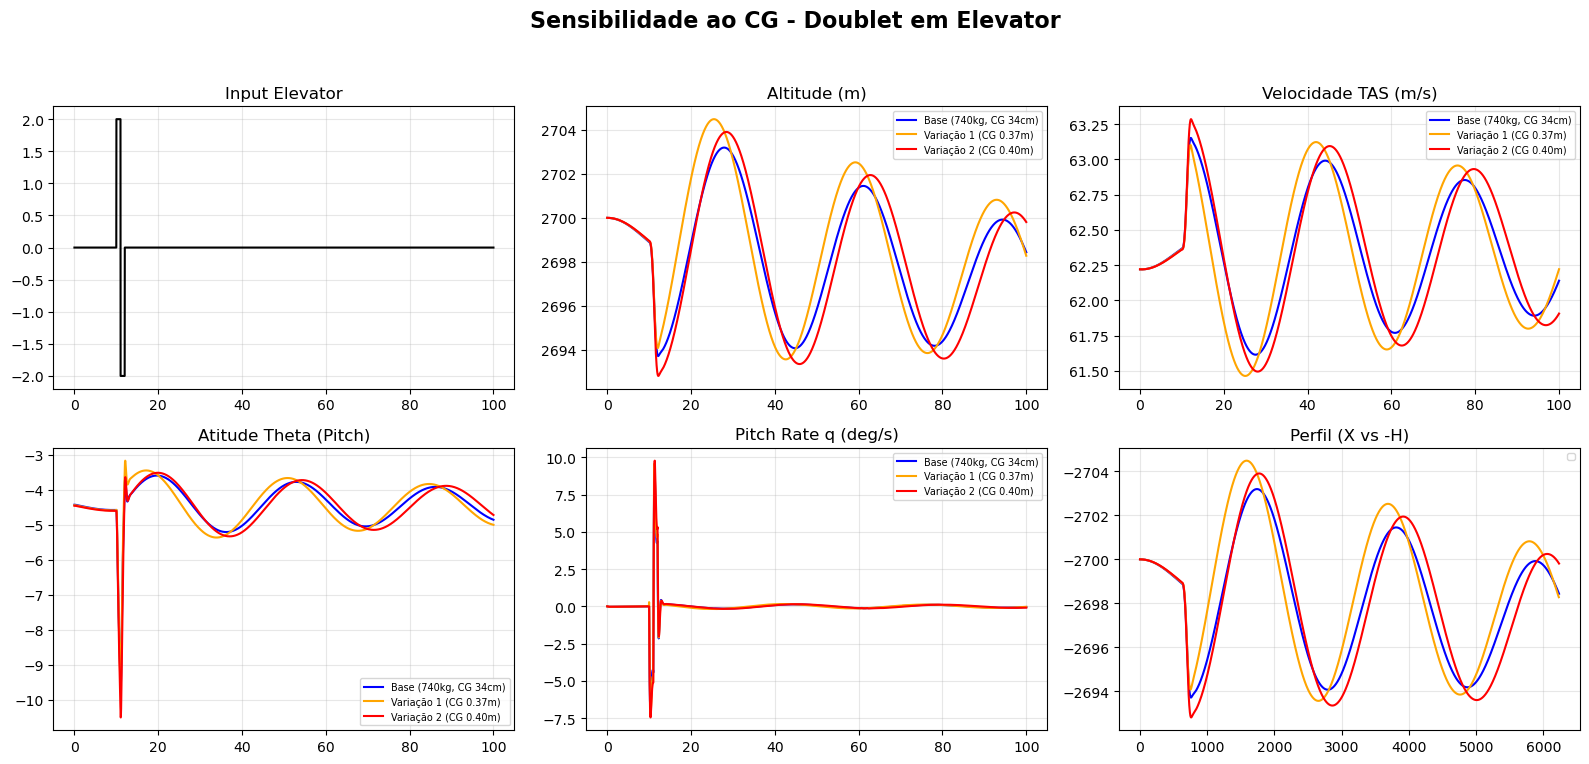

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


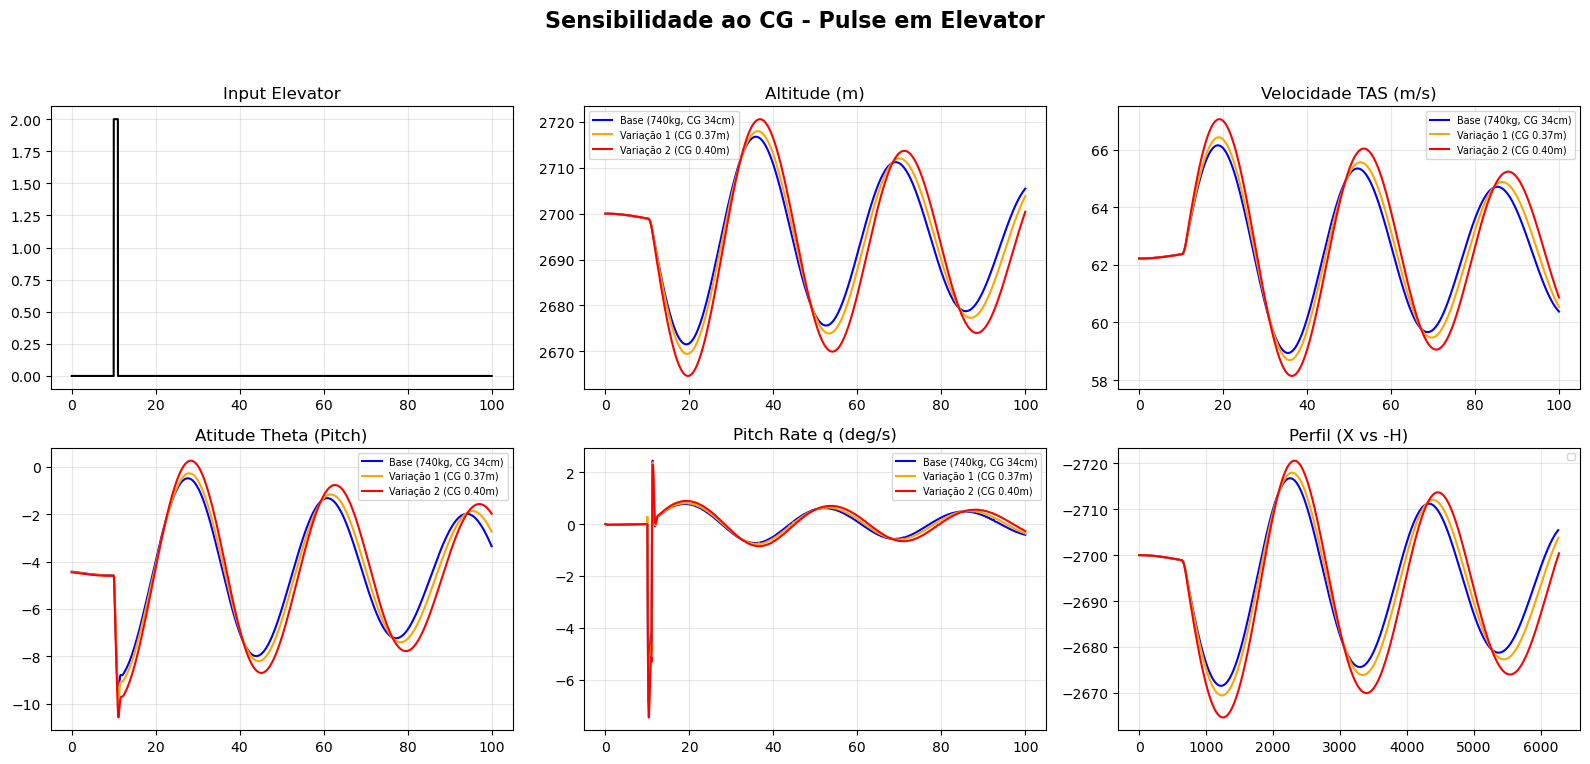

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


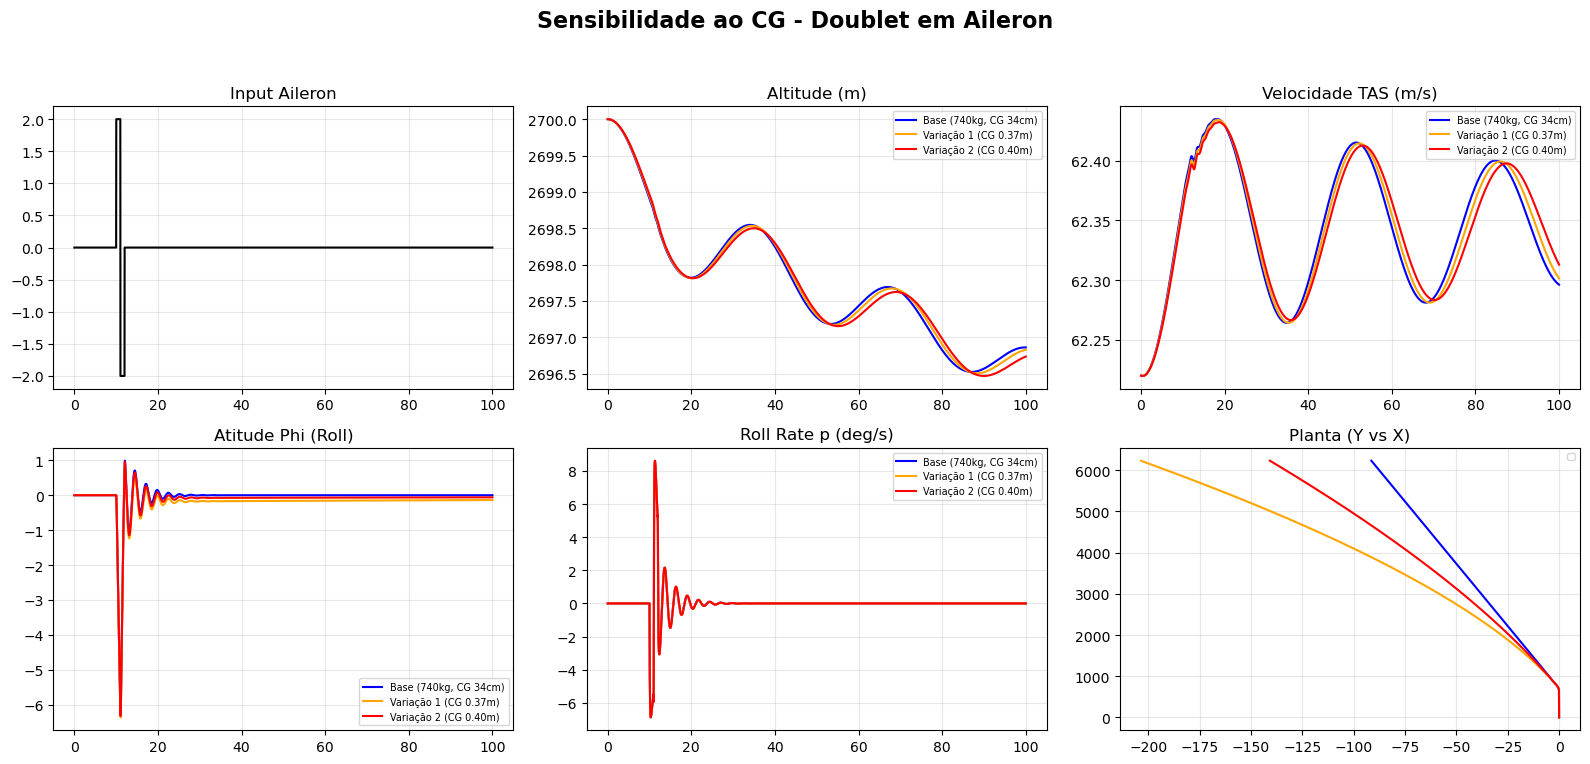

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


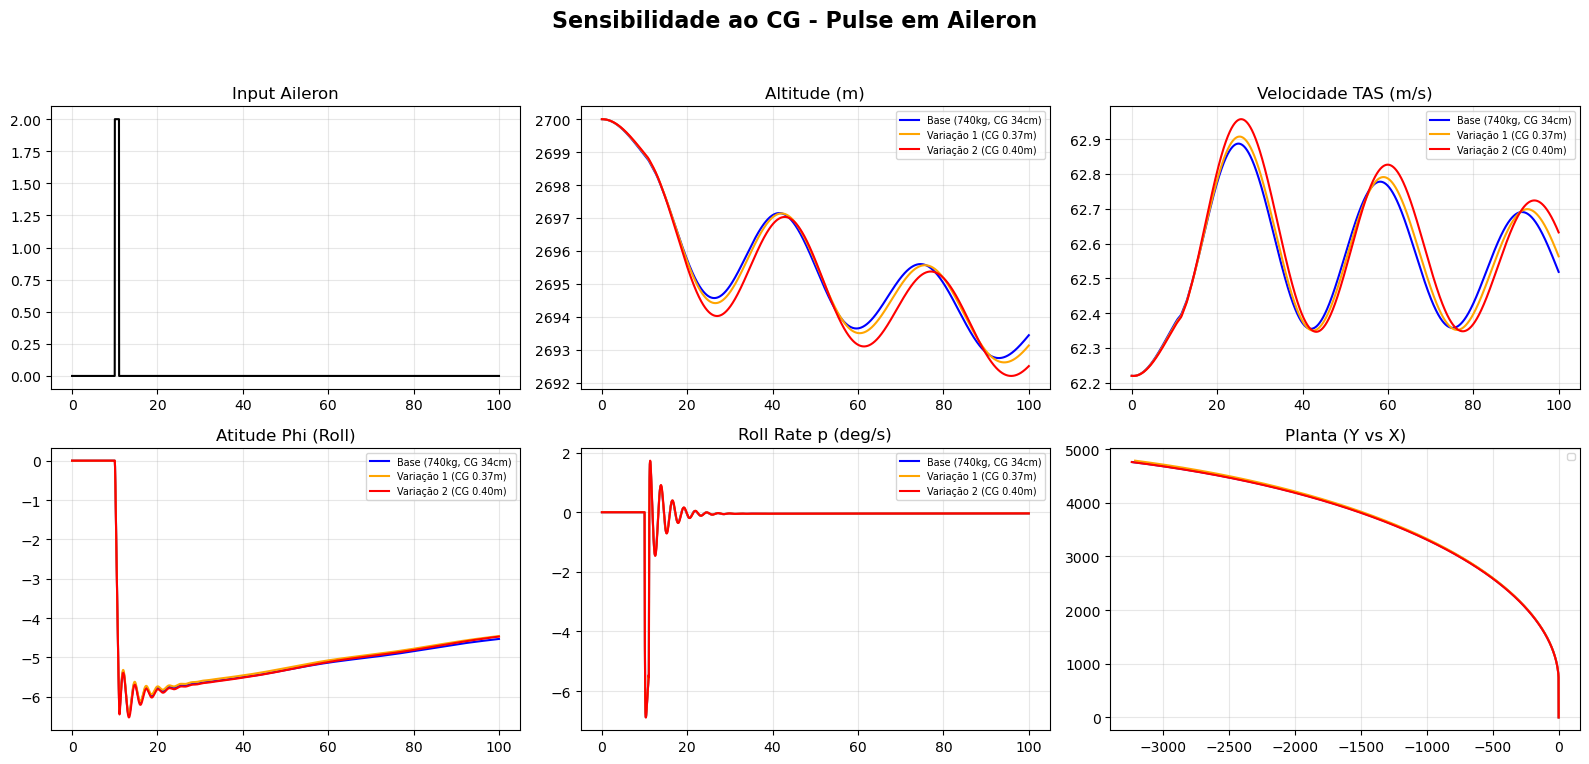

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


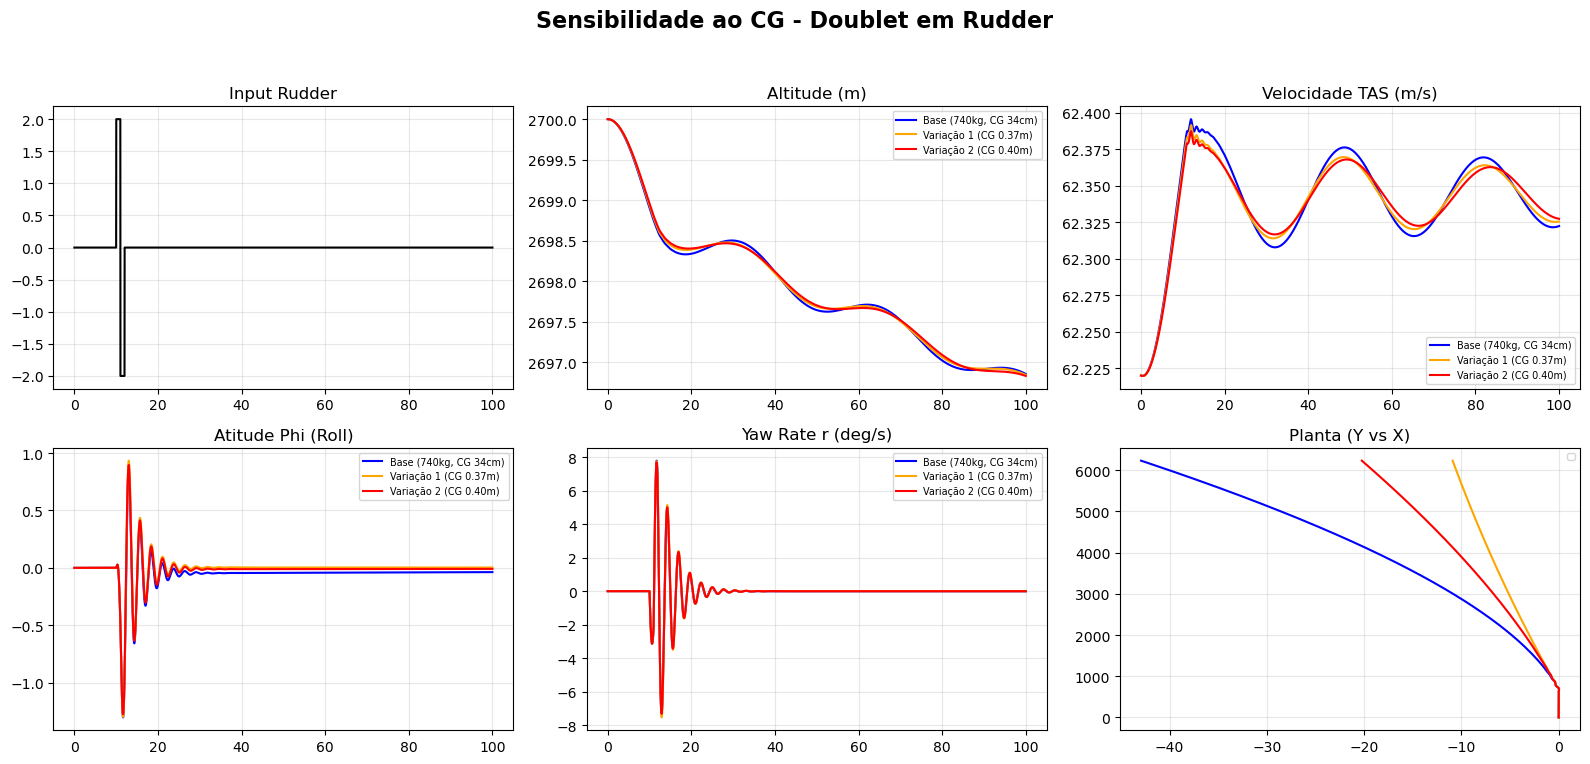

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


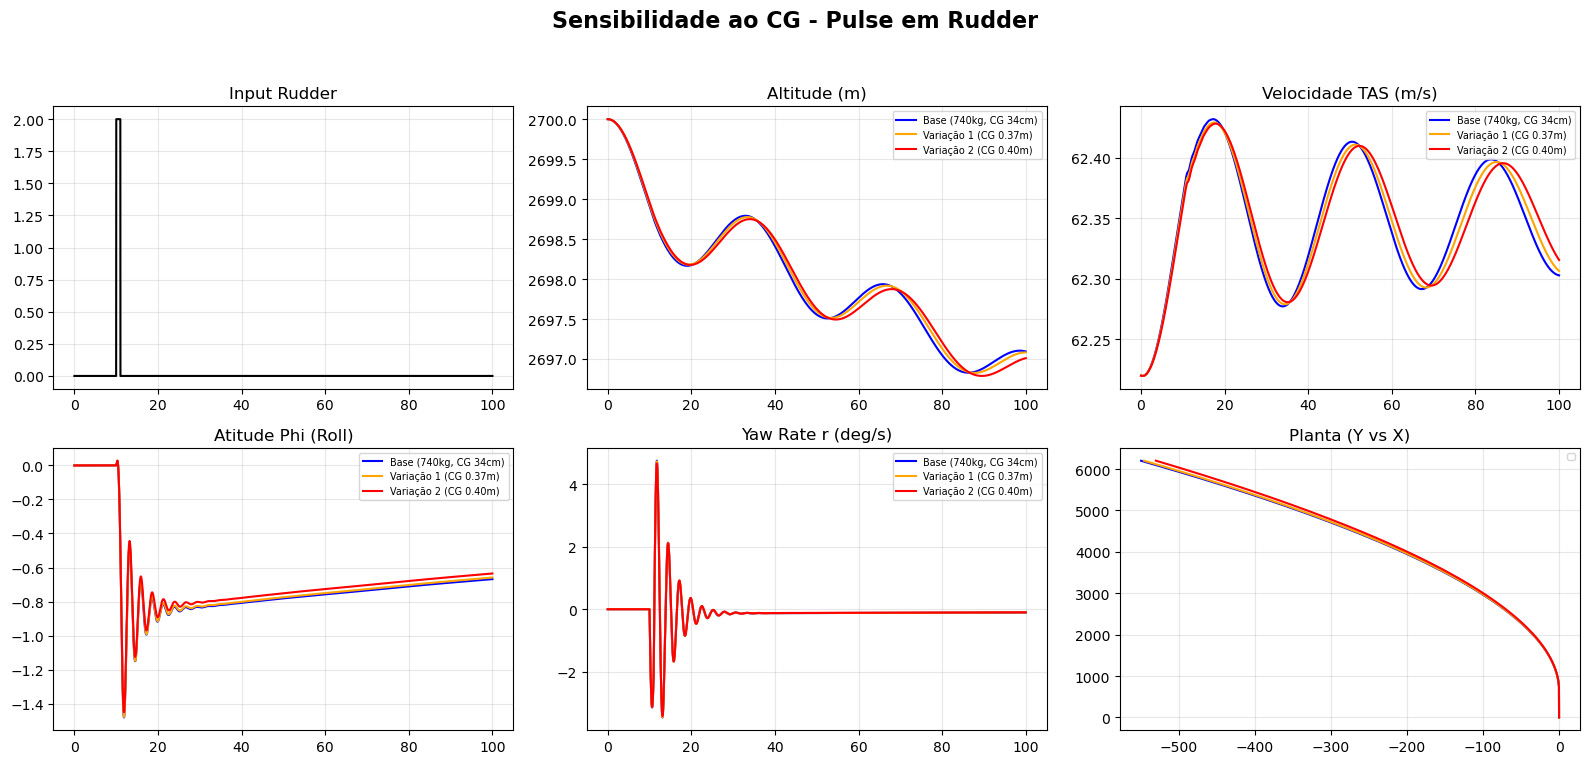

In [53]:
# ==========================================================
# EXECUTAR AS DUAS BATERIAS
# ==========================================================
configs_cg = [CONFIG_BASE, CONFIG_VAR1, CONFIG_VAR2]

# 1. Visão Geral (Fugóide e Espiral) - 600 segundos
#run_comparative_batch(configs_cg, zoom=False, title_prefix="Sensibilidade ao CG")

# 2. Visão Dinâmica (Curto Período e Dutch Roll) - 20 segundos
run_comparative_batch(configs_cg, zoom=True, title_prefix="Sensibilidade ao CG")

---
# 4. Análise de Sensibilidade: Posição do Centro de Gravidade (CG)
**Objetivo:** Avaliar a influência da inércia e do carregamento alar na resposta dinâmica da aeronave.

Para isolar os efeitos puramente inerciais e de peso, manteve-se a posição do CG fixa em **31.8% (0.34 m)** e variou-se a massa total da aeronave entre três condições operacionais:

| Configuração | Massa Total (kg) | Descrição |
| :--- | :---: | :--- |
| 🔵 **Caso Base** | **740 kg** | Peso Máximo (MTOW). Maior inércia rotacional. |
| 🟠 **Variação 1** | **627 kg** | Peso Operacional Típico/Leve. |
| 🔴 **Variação 2** | **575 kg** | Peso Mínimo. Menor inércia rotacional. |

In [56]:
# =============================================================================
# VARIAÇÃO DE MASSA: LEVE (627kg)
# =============================================================================
CONFIG_MASS_LEVE = {
    'name': 'Massa Leve (627kg)',
    
    'params': {
        'm': 627.0,       
        'S': 17.87, 'b': 17.5, 'c': 1.07,
        'g': 9.798, 'rho': 0.871,
        'Ixx': 3000.0, 'Iyy': 1438.0, 'Izz': 3867.0, 'Ixz': 0.0,
    },
    
    'trim': {
        'V': 62.22,
        'alpha_rad': radians(-4.80529),
        'delta_e_rad': radians(8.16821),
    },
    
    'derivatives': {
        # --- Longitudinais ---
        'CL_ref': 0.20391,
        'CD_ref': 0.00092 * 10, 
        
        'CL_a': 5.915274, 
        'CL_q': 9.822763, 
        'CL_de': 0.005129 * (180/pi),
        
        'Cm_ref': 0.0,
        'Cm_a': -1.607865,
        'Cm_q': -21.377563,
        'Cm_de': -0.024352 * (180/pi),
        
        # --- Látero-Direcionais ---
        'CY_b': -0.178616,
        'CY_p': -0.073999,
        'CY_r': 0.116818,
        'CY_da': -0.000453 * (180/pi),
        'CY_dr': 0.002197 * (180/pi),
        
        'Cl_b': -0.059007,
        'Cl_p': -0.644779,
        'Cl_r': 0.070443,
        'Cl_da': -0.005786 * (180/pi),
        'Cl_dr': 0.000148 * (180/pi),
        
        'Cn_b': 0.045274,
        'Cn_p': -0.018525,
        'Cn_r': -0.030503,
        'Cn_da': 0.000543 * (180/pi),
        'Cn_dr': -0.000666 * (180/pi),
    }
}

# =============================================================================
# VARIAÇÃO DE MASSA: MÍNIMA (575kg)
# =============================================================================
CONFIG_MASS_MIN = {
    'name': 'Massa Mínima (575kg)',
    
    'params': {
        'm': 575.0,       
        'S': 17.87, 'b': 17.5, 'c': 1.07,
        'g': 9.798, 'rho': 0.871,
        'Ixx': 2752.0, 'Iyy': 1318.0, 'Izz': 3546.0, 'Ixz': 0.0,
    },
    
    'trim': {
        'V': 62.22,
        'alpha_rad': radians(-4.97919),
        'delta_e_rad': radians(8.37091),
    },
    
    'derivatives': {
        # --- Longitudinais ---
        'CL_ref': 0.18700,
        'CD_ref': 0.00079 * 10, 
        
        'CL_a': 5.915276, 
        'CL_q': 9.823785, 
        'CL_de': 0.005127 * (180/pi),
        
        'Cm_ref': 0.0,
        'Cm_a': -1.601720,
        'Cm_q': -21.335037,
        'Cm_de': -0.024327 * (180/pi),
        
        # --- Látero-Direcionais ---
        'CY_b': -0.178496,
        'CY_p': -0.074984,
        'CY_r': 0.116122,
        'CY_da': -0.000450 * (180/pi),
        'CY_dr': 0.002195 * (180/pi),
        
        'Cl_b': -0.058691,
        'Cl_p': -0.644865,
        'Cl_r': 0.066407,
        'Cl_da': -0.005786 * (180/pi),
        'Cl_dr': 0.000148 * (180/pi),
        
        'Cn_b': 0.045342,
        'Cn_p': -0.016920,
        'Cn_r': -0.030390,
        'Cn_da': 0.000550 * (180/pi),
        'Cn_dr': -0.000665 * (180/pi),
    }
}

--- GERANDO GRÁFICOS COMPARATIVOS (ZOOM=LIGADO) ---


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


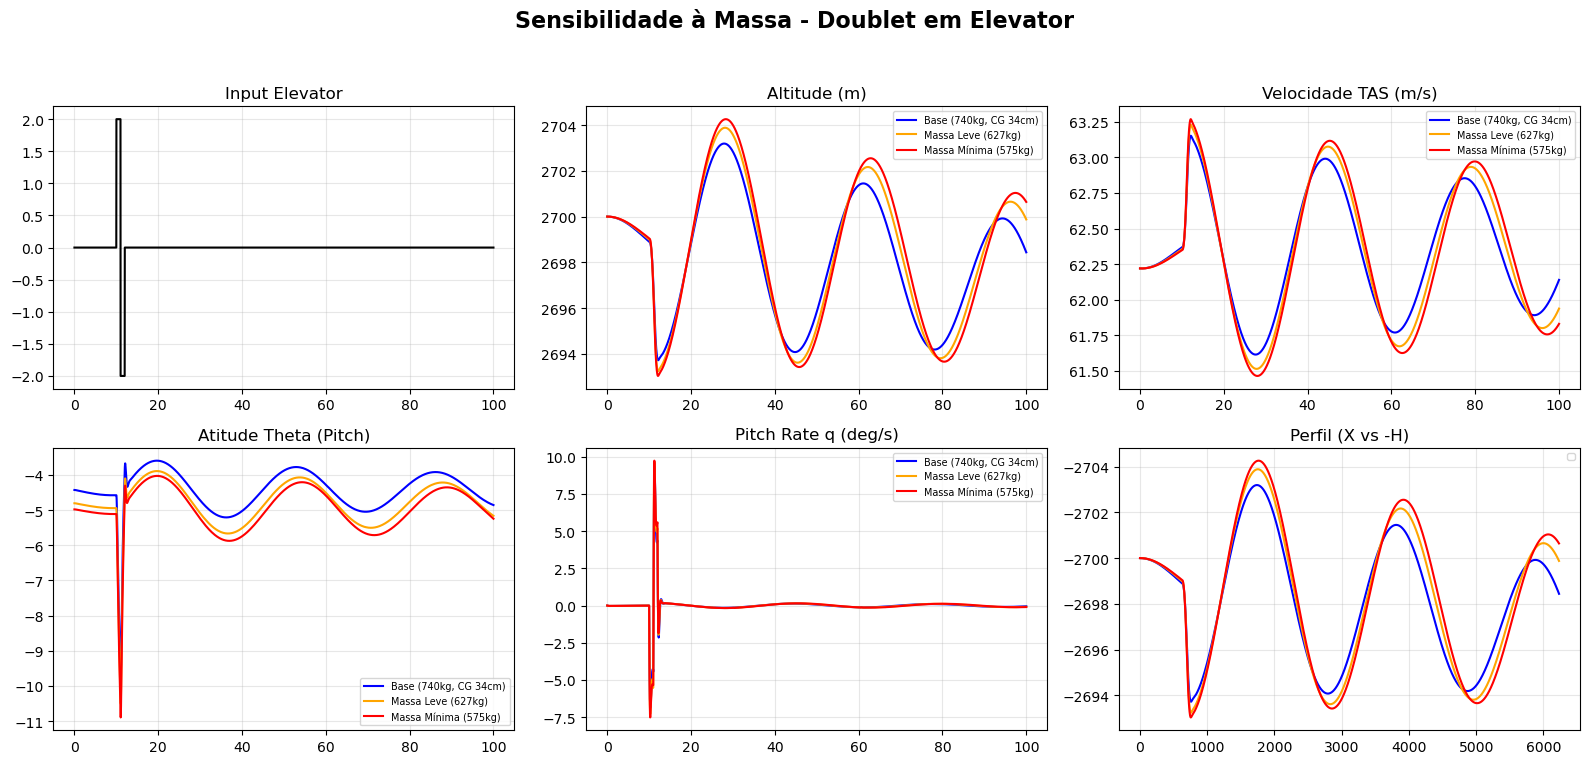

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


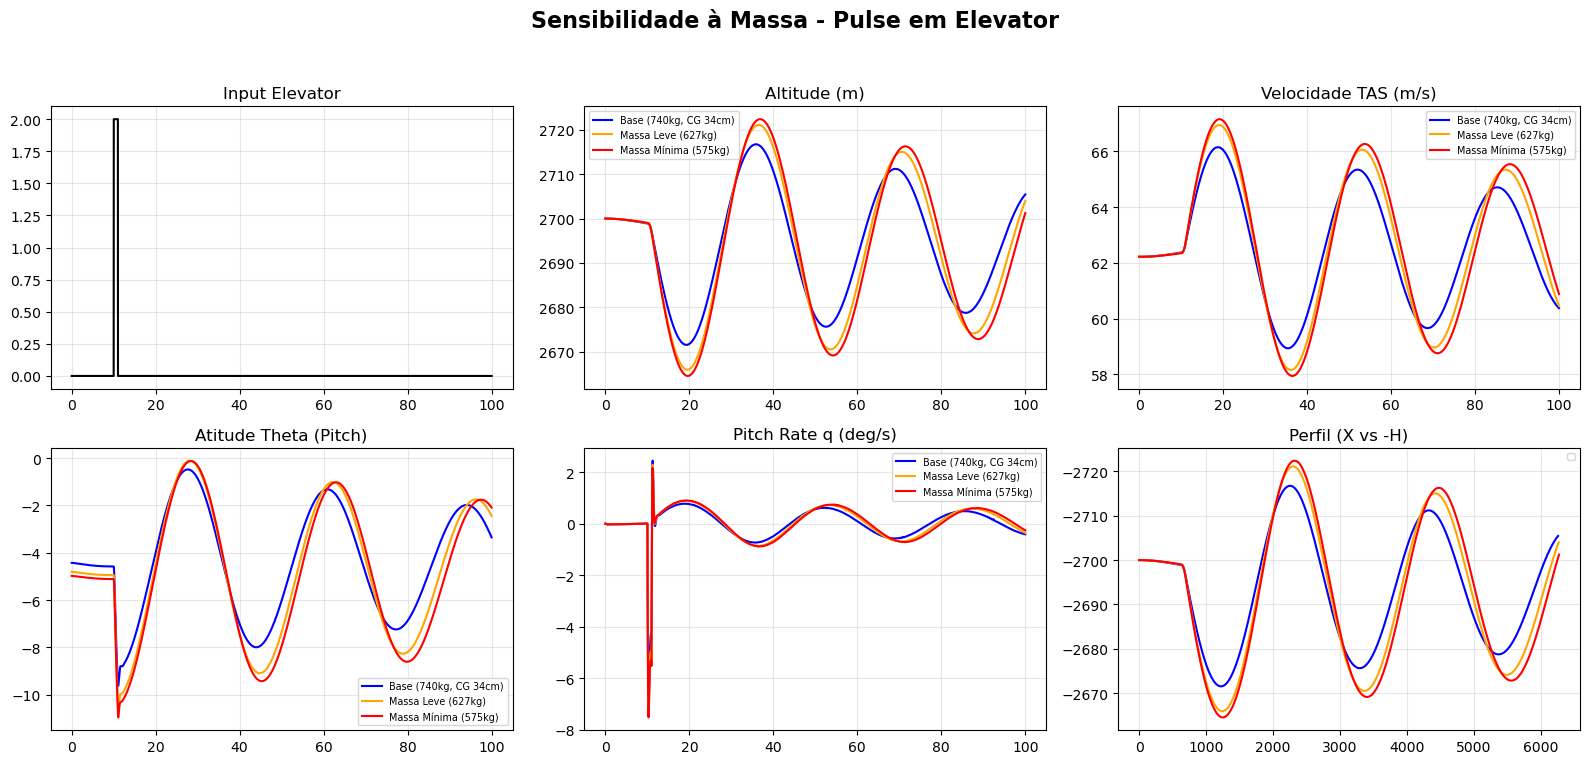

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


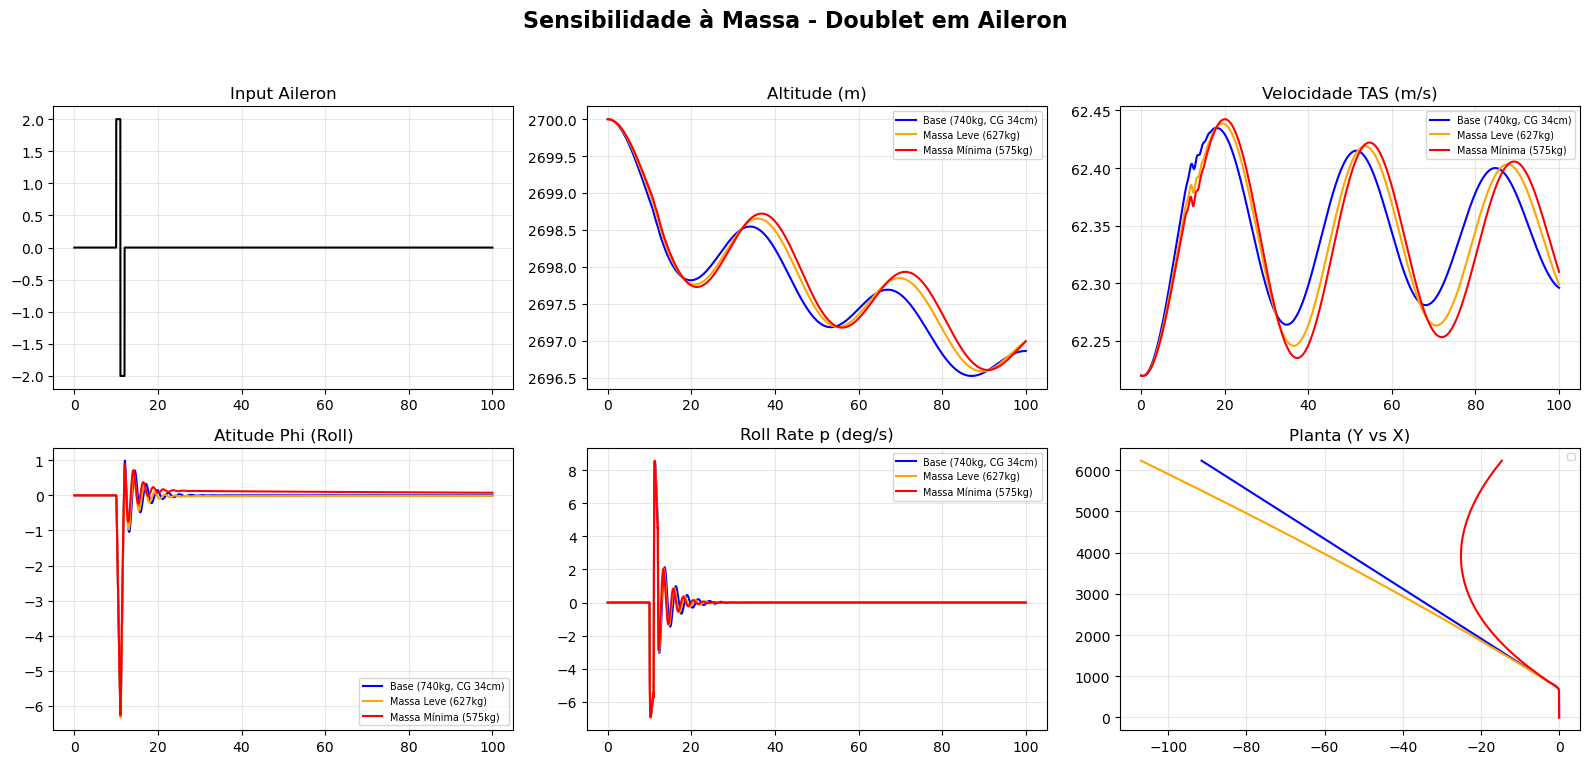

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


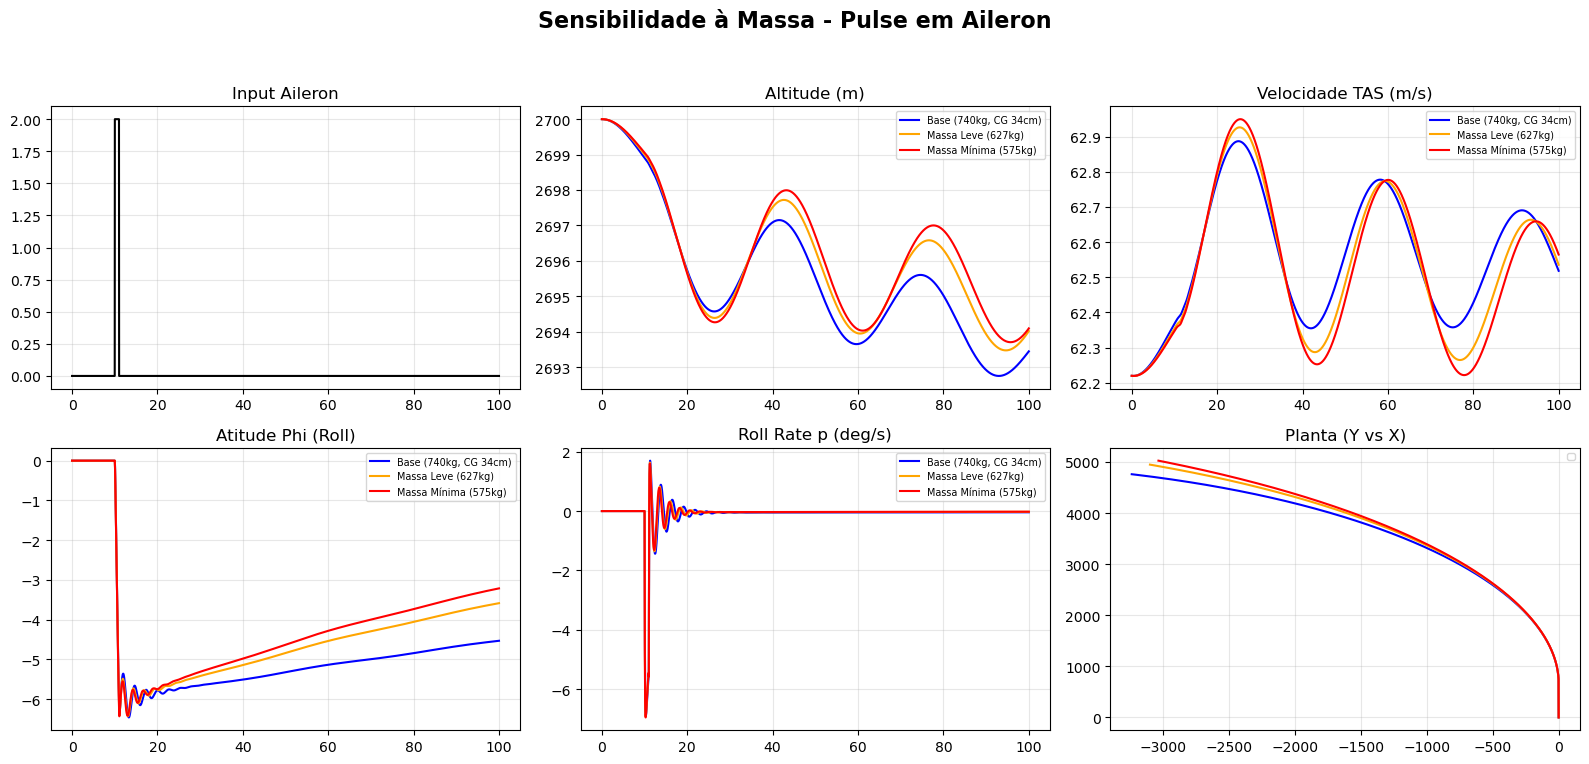

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


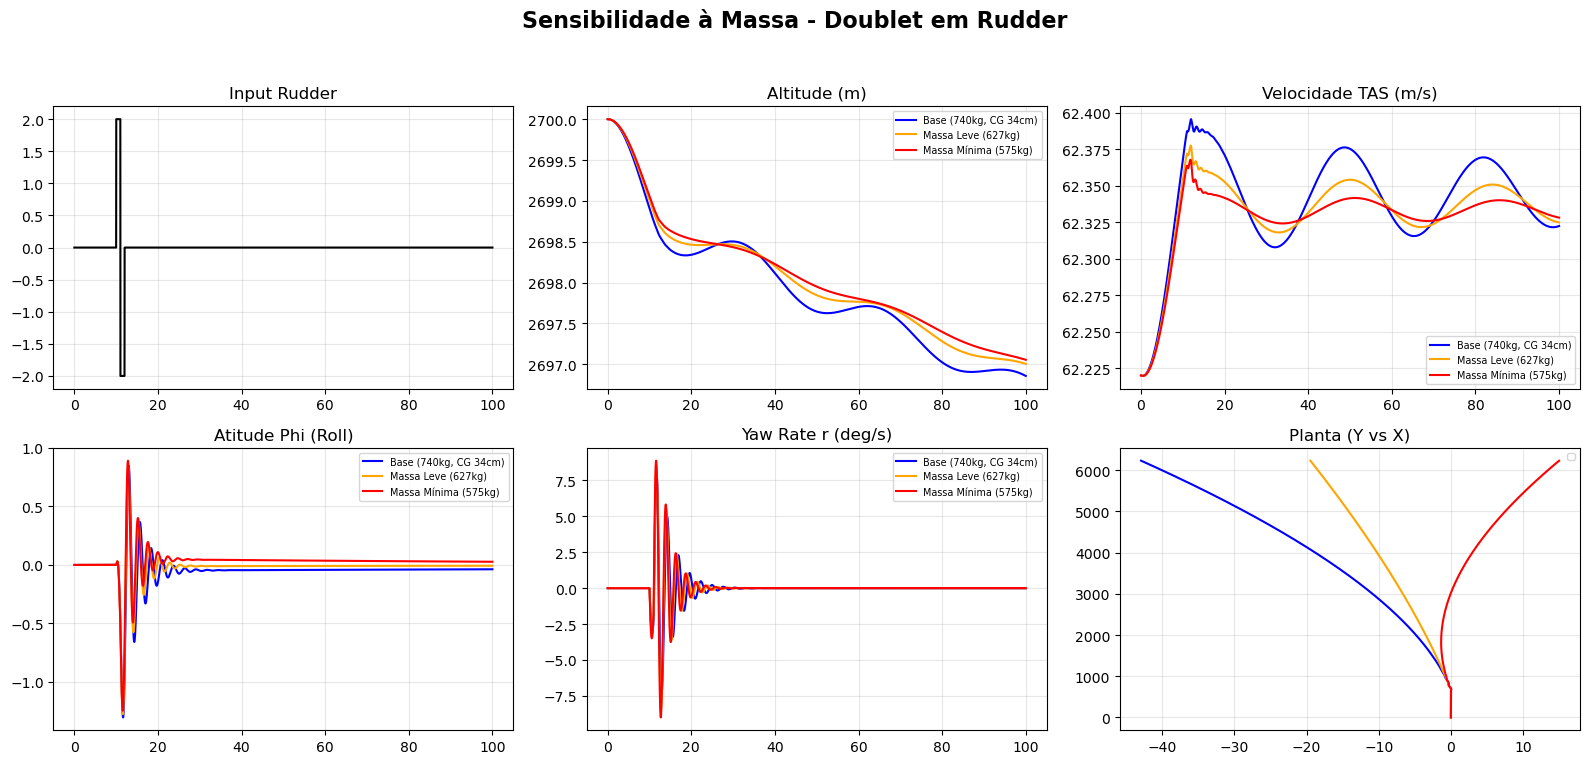

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


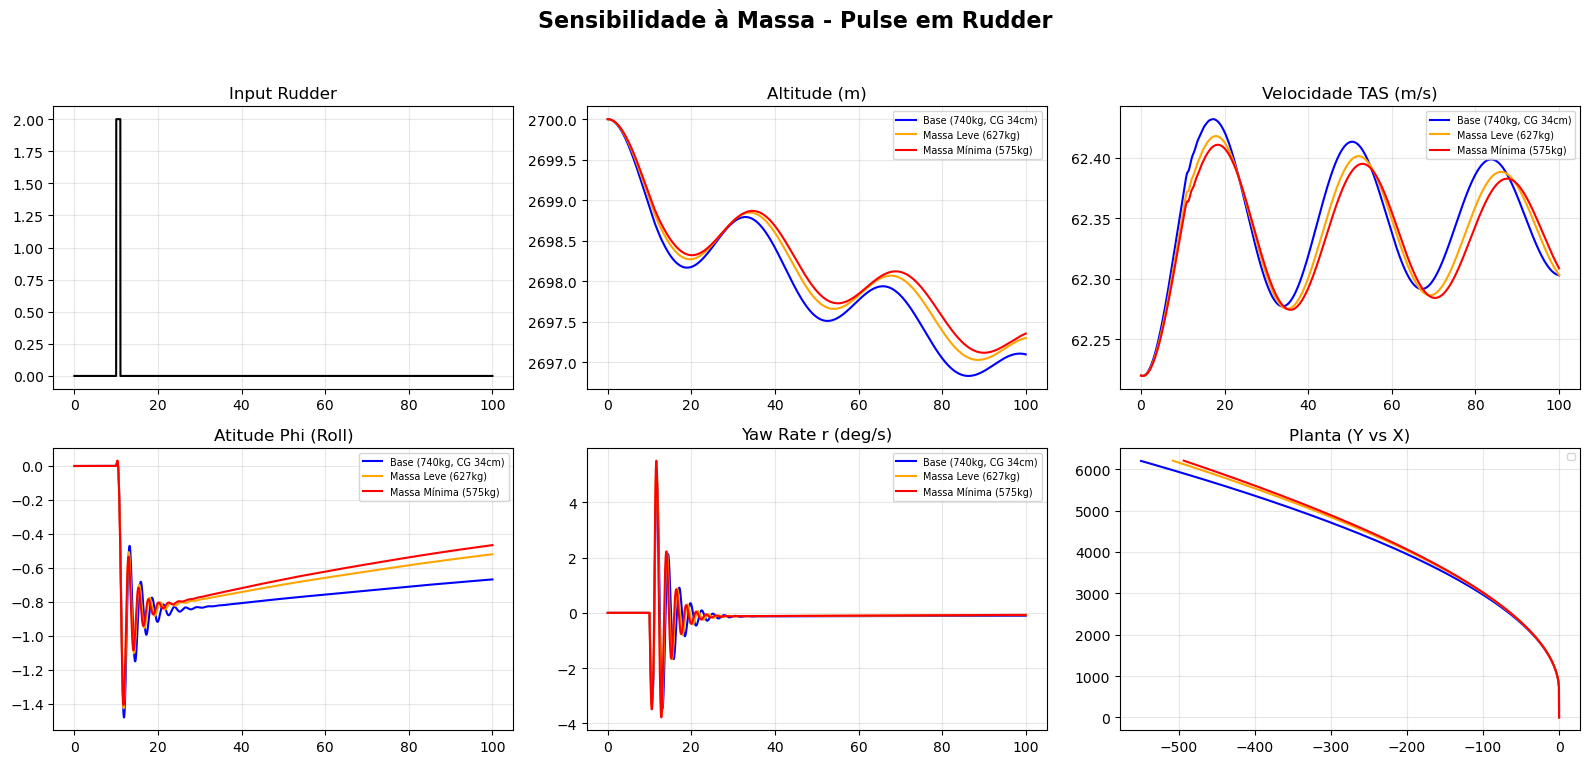

In [57]:
# =============================================================================
# EXECUTAR COMPARATIVO DE MASSA
# =============================================================================
# Lista: Pesado (Base) -> Leve -> Mínimo
configs_mass = [CONFIG_BASE, CONFIG_MASS_LEVE, CONFIG_MASS_MIN]

# 1. Visão Geral (Fugóide e Espiral) - 600 segundos
#run_comparative_batch(configs_mass, zoom=False, title_prefix="Sensibilidade à Massa")

# 2. Visão Dinâmica (Curto Período e Dutch Roll) - 20 segundos
run_comparative_batch(configs_mass, zoom=True, title_prefix="Sensibilidade à Massa")